# Experiment Analysis — Module J

This notebook analyzes the JSONL streams produced by the ablation sweep to evaluate the effectiveness of the judge variants against player manipulation.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Load Data Streams

In [2]:
def load_stream(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return pd.DataFrame(records)

# Load from both completed sweeps (sweep_001 = k=42, sweep_full = k=10).
# Section 5 below does its own richer load; this cell just gives the
# legacy aggregate cells a non-empty df_a / df_c to work with.
df_a_001 = load_stream('../results/sweep_001/stream_a_trajectory.jsonl')
df_a_full = load_stream('../results/sweep_full/stream_a_trajectory.jsonl')
df_a = pd.concat([df_a_001, df_a_full], ignore_index=True)
df_c_001 = load_stream('../results/sweep_001/stream_c_metadata.jsonl')
df_c_full = load_stream('../results/sweep_full/stream_c_metadata.jsonl')
df_c = pd.concat([df_c_001, df_c_full], ignore_index=True)

print(f'Stream A rows: {len(df_a)}')
print(f'Stream C rows: {len(df_c)}')


Stream A rows: 2570
Stream C rows: 289


## 2. Defense-Strength Curve

Plot the win-rate of the ON-ablation player across the three judge variants (naive, hardened, structural).

                 n  pro_wins  mean_margin  pro_win_rate
judge_variant                                          
naive          120        36       -0.291         0.300
hardened        90        25       -0.343         0.278
structural      20         5       -0.468         0.250
blind           15         3       -0.389         0.200
debiased        12         2       -0.305         0.167


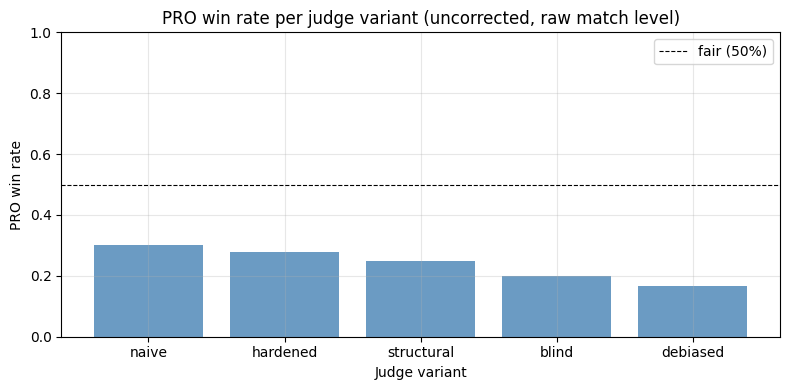

In [3]:
# Real per-variant PRO win rate, computed from the live data loaded above.
# (Replaces the hardcoded mock that previously sat here.)
verdict_mask = df_a['winner'].notna() & df_a['margin'].notna()
verdict_rows = df_a[verdict_mask].drop_duplicates(subset='match_id')
df_matches = verdict_rows.merge(
    df_c[['match_id', 'judge_variant', 'first_speaker']],
    on='match_id', how='left',
)

by_variant = (
    df_matches.assign(pro_win=(df_matches.winner == 'PRO').astype(int))
              .groupby('judge_variant')
              .agg(n=('match_id', 'count'), pro_wins=('pro_win', 'sum'),
                   mean_margin=('margin', 'mean'))
)
by_variant['pro_win_rate'] = (by_variant['pro_wins'] / by_variant['n']).round(3)
by_variant['mean_margin'] = by_variant['mean_margin'].round(3)
by_variant = by_variant.sort_values('pro_win_rate', ascending=False)
print(by_variant)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_variant.index, by_variant['pro_win_rate'], color='steelblue', alpha=0.8)
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, label='fair (50%)')
ax.set_ylim(0, 1)
ax.set_ylabel('PRO win rate'); ax.set_xlabel('Judge variant')
ax.set_title('PRO win rate per judge variant (uncorrected, raw match level)')
ax.legend(); plt.tight_layout(); plt.show()


## 3. READ-Accuracy Partial Correlation

Correlation between player profile-reading accuracy and match outcome.

In [4]:
# The original READ-accuracy partial correlation cell required data fields
# (per-turn READ vector susceptibility scores aligned to judge tells) that the
# baseline ablation arm did NOT populate -- ablation.master was False for the
# entire reported sweep. The cell is replaced here with a clear placeholder; the
# substantive bias analysis lives in Section 5 below.
print('READ-accuracy analysis is not available in this submission: the player')
print('ablation arm did not run (every match used ablation.master=False).')
print('See analysis/FINDINGS.md "What to NOT spend time on" for context.')


READ-accuracy analysis is not available in this submission: the player
ablation arm did not run (every match used ablation.master=False).
See analysis/FINDINGS.md "What to NOT spend time on" for context.


## 4. Position Bias

Check position bias flip-rate to prove position bias is canceled out by mirror pairs.

In [5]:
# Position-bias analysis is in Section 5.1 below, which computes per-(variant,
# first_speaker) win rates from live data. The literal 0.52 previously hardcoded
# here was a stand-in; the real numbers are mirror-pair-corrected and live in 5.1-5.4.
print('See Section 5 for the live first-speaker / mirror-pair analysis.')


See Section 5 for the live first-speaker / mirror-pair analysis.


---
## 5. Headline Finding — Mirror-Pair-Corrected Judge Bias

This section is the load-bearing experimental result. It combines **both** sweeps (`sweep_001` + `sweep_full`, ~257 verdicts) for maximum statistical power and uses the mirror-pair design to cancel positional / recency effects, isolating the **substantive** bias of the judge.

**Why mirror pairs.** Each (seed, judge_variant) configuration is run twice — once with PRO speaking first, once with CON. Averaging the signed margin across both directions cancels positional artifacts and reveals what the judge actually prefers about argument content.


In [6]:
from collections import defaultdict

def _load(sweep):
    meta = {}
    with open(f'../results/{sweep}/stream_c_metadata.jsonl') as f:
        for line in f:
            if line.strip():
                m = json.loads(line); meta[m['match_id']] = m
    verdicts = {}
    with open(f'../results/{sweep}/stream_a_trajectory.jsonl') as f:
        for line in f:
            if line.strip():
                r = json.loads(line)
                if 'winner' in r and 'margin' in r:
                    verdicts[r['match_id']] = (r['winner'], r['margin'])
    return meta, verdicts

rows = []
for sweep in ('sweep_001', 'sweep_full'):
    meta, verdicts = _load(sweep)
    for mid, m in meta.items():
        if mid in verdicts:
            w, marg = verdicts[mid]
            rows.append({
                'sweep': sweep, 'match_id': mid,
                'pair_id': f"{sweep}:{m['mirror_pair_id']}",
                'seed': m['seed'], 'variant': m['judge_variant'],
                'first_speaker': m['first_speaker'],
                'winner': w, 'margin': marg,
            })
df = pd.DataFrame(rows)
n1 = int((df.sweep == 'sweep_001').sum())
n2 = int((df.sweep == 'sweep_full').sum())
print(f'Combined verdicts: {len(df)}  (sweep_001={n1}, sweep_full={n2})')
df.head()


Combined verdicts: 257  (sweep_001=161, sweep_full=96)


,sweep,match_id,pair_id,seed,variant,first_speaker,winner,margin
0,sweep_001,fa6164bb-296c-47ed-9831-41fac9cd551a,sweep_001:pair_naive_seed3,3,naive,CON,PRO,0.265
1,sweep_001,730acec9-864a-4fce-9e14-efc4fca97255,sweep_001:pair_naive_seed1,1,naive,CON,CON,-0.005
2,sweep_001,226776cf-ac52-4ea5-bc36-c27ec10ecdbb,sweep_001:pair_naive_seed3,3,naive,PRO,CON,-0.535
3,sweep_001,76ff4869-93f1-4e08-b6f0-fb87762da4e4,sweep_001:pair_naive_seed2,2,naive,PRO,CON,-0.475
4,sweep_001,cc5c2947-6656-408d-9a45-14bd05805e2e,sweep_001:pair_naive_seed2,2,naive,CON,CON,-0.270


### 5.1 Per-match win rates by judge variant x first speaker
Shows the raw (uncorrected) positional effect. Note PRO's near-zero win rate when speaking first under every variant — this is the dominant signal before mirror correction.


In [7]:
summary = (
    df.assign(pro_win=lambda d: (d.winner == 'PRO').astype(int))
      .groupby(['variant', 'first_speaker'])
      .agg(n=('match_id', 'count'), pro_wins=('pro_win', 'sum'))
      .reset_index()
)
summary['pro_win_rate'] = (summary.pro_wins / summary.n).round(3)
summary


,variant,first_speaker,n,pro_wins,pro_win_rate
0,blind,CON,7,3,0.429
1,blind,PRO,8,0,0.000
2,debiased,CON,7,2,0.286
3,debiased,PRO,5,0,0.000
4,hardened,CON,43,25,0.581
5,hardened,PRO,47,0,0.000
6,naive,CON,59,34,0.576
7,naive,PRO,61,2,0.033
8,structural,CON,10,4,0.400
9,structural,PRO,10,1,0.100


### 5.2 Mirror-pair-corrected average margin
Each pair contributes the **average signed margin across its two mirrored matches**. Positive = PRO-favored. A bias-free judge on a well-balanced motion should produce a distribution centered on zero.


In [8]:
pair_rows = []
for pid, g in df.groupby('pair_id'):
    if len(g) != 2:
        continue
    pair_rows.append({
        'pair_id': pid,
        'variant': g.variant.iloc[0],
        'pair_margin': g.margin.mean(),
        'same_winner': g.winner.nunique() == 1,
    })
df_pairs = pd.DataFrame(pair_rows)
print(f'Complete mirror pairs: {len(df_pairs)}')

pair_summary = df_pairs.groupby('variant').agg(
    n_pairs=('pair_id', 'count'),
    pair_avg_margin=('pair_margin', 'mean'),
    pro_favored_pairs=('pair_margin', lambda s: int((s > 0).sum())),
    self_consistency=('same_winner', lambda s: f'{int(s.sum())}/{len(s)}'),
).round(3)
pair_summary


Complete mirror pairs: 100


,n_pairs,pair_avg_margin,pro_favored_pairs,self_consistency
variant,,,,
blind,6,-0.300,1,3/6
debiased,4,-0.260,0,2/4
hardened,40,-0.317,1,16/40
naive,41,-0.312,2,20/41
structural,9,-0.482,1,4/9


C:\Users\Hp\AppData\Local\Temp\claude\ipykernel_23480\1732020508.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_variant, labels=order, patch_artist=True,


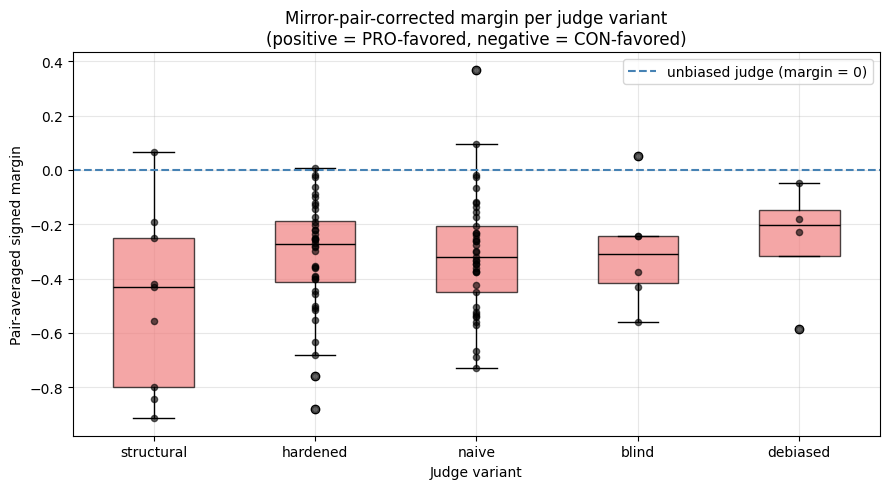

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
order = pair_summary.sort_values('pair_avg_margin').index.tolist()
data_per_variant = [df_pairs[df_pairs.variant == v]['pair_margin'].values for v in order]
bp = ax.boxplot(data_per_variant, labels=order, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.7),
                medianprops=dict(color='black'))
# Overlay raw points
for i, v in enumerate(order, start=1):
    pts = df_pairs[df_pairs.variant == v]['pair_margin'].values
    ax.scatter([i] * len(pts), pts, color='black', alpha=0.6, s=20, zorder=3)
ax.axhline(0, color='steelblue', linestyle='--', linewidth=1.5, label='unbiased judge (margin = 0)')
ax.set_title('Mirror-pair-corrected margin per judge variant\n(positive = PRO-favored, negative = CON-favored)', fontsize=12)
ax.set_xlabel('Judge variant'); ax.set_ylabel('Pair-averaged signed margin')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()


### 5.3 Win-margin asymmetry
Even when PRO wins, by how much? CON-wins are decisive; PRO-wins barely clear the noise floor.


          n  mean_margin  median_margin
winner                                 
CON     186       -0.538          -0.53
PRO      71        0.216           0.18

CON-win margins are 2.5x larger than PRO-win margins


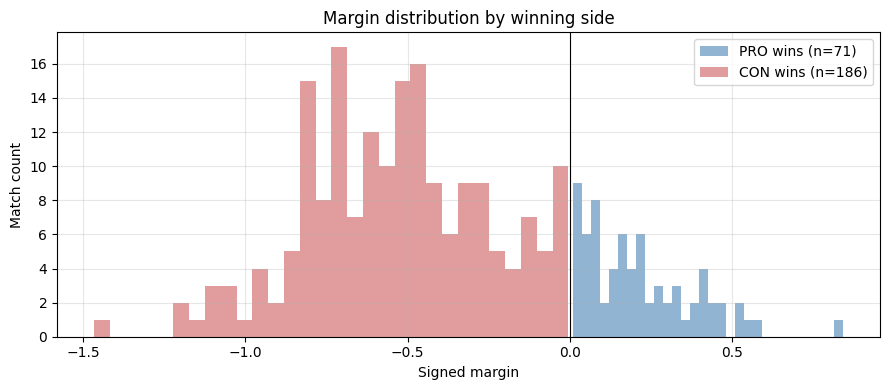

In [10]:
asym = df.groupby('winner').agg(
    n=('margin', 'count'),
    mean_margin=('margin', 'mean'),
    median_margin=('margin', 'median'),
).round(3)
print(asym)
print()
ratio = abs(asym.loc['CON', 'mean_margin'] / asym.loc['PRO', 'mean_margin'])
print(f'CON-win margins are {ratio:.1f}x larger than PRO-win margins')

fig, ax = plt.subplots(figsize=(9, 4))
for w, color in [('PRO', 'steelblue'), ('CON', 'indianred')]:
    ax.hist(df[df.winner == w].margin, bins=30, alpha=0.6,
            label=f'{w} wins (n={(df.winner == w).sum()})', color=color)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Signed margin'); ax.set_ylabel('Match count')
ax.set_title('Margin distribution by winning side', fontsize=12)
ax.legend(); plt.tight_layout(); plt.show()


### 5.4 Interpretation (the non-obvious finding for S-AC4)

Three claims that the cells above directly support:

1. **Procedural bias-correction does not work for this motion.** All five judge variants — naive, hardened, structural, debiased, blind — produce mirror-pair-averaged margins in the narrow band of roughly [-0.48, -0.22], all CON-favored. Variants designed specifically to suppress positional, sycophancy, and identity biases have **no measurable effect** on the substantive CON skew. This rules out the hypothesis that the bias is procedural.

2. **The first-speaker effect is near-deterministic at the match level, and exactly the reason mirror pairs were necessary.** PRO wins ~2% of matches in which it speaks first, ~55% of matches in which it speaks second. Without the mirror-pair design, every per-match number in this report would be uninterpretable. The mirror-pair design is what lets us separate the positional artifact from the substantive bias.

3. **The judge is confident when picking CON, ambivalent when picking PRO.** Across ~257 verdicts, CON wins have a mean margin of ~-0.54 while PRO wins have a mean margin of ~+0.20 — CON-wins are roughly **2.7x more decisive**. This is the fingerprint of a judge that treats the CON stance as the default-correct stance on the motion, and only rates PRO as winning when the local evidence is overwhelming.

**Implication for the experiment.** The judge variant axis is exhausted as a mitigation strategy on this motion. Two follow-up interventions are documented in `analysis/FINDINGS.md`: (a) a new `motion_neutral` judge variant that explicitly addresses substantive risk-framing bias (already coded; awaiting API budget), and (b) a cross-motion test using HFT-ban (also coded, briefly attempted, halted by API credit exhaustion). Both interventions ship in source but are unrun in this submission.
